In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer


Importing Dataset

In [2]:
df=pd.read_csv(r"C:\Users\hp\Downloads\Skill_Nexis_Internship_Projects\Week_1_Project\Titanic_Survival_Prediction\Data\Titanic-Dataset.csv",na_values=['NaN','nan','na','inf','Null','None'])

Initial Summary 

In [3]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.550,NaN,S
464,465,0,3,"Maisner, Mr. Simon",male,NaN,0,0,A/S 2816,8.050,NaN,S
431,432,1,3,"Thorneycroft, Mrs. Percival (Florence Kate White)",female,NaN,1,0,376564,16.100,NaN,S
282,283,0,3,"de Pelsmaeker, Mr. Alfons",male,16.0,0,0,345778,9.500,NaN,S
639,640,0,3,"Thorneycroft, Mr. Percival",male,NaN,1,0,376564,16.100,NaN,S
556,557,1,1,"Duff Gordon, Lady. (Lucille Christiana Sutherl...",female,48.0,1,0,11755,39.600,A16,C
795,796,0,2,"Otter, Mr. Richard",male,39.0,0,0,28213,13.000,NaN,S
184,185,1,3,"Kink-Heilmann, Miss. Luise Gretchen",female,4.0,0,2,315153,22.025,NaN,S
565,566,0,3,"Davies, Mr. Alfred J",male,24.0,2,0,A/4 48871,24.150,NaN,S
151,152,1,1,"Pears, Mrs. Thomas (Edith Wearne)",female,22.0,1,0,113776,66.600,C2,S


In [4]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 285.6 KB


In [5]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


Correcting Datatypes

In [6]:
df['Age']=pd.to_numeric(df['Age'],errors='coerce').round().astype('Int64')

Creating New Features

In [7]:
'''Extracting title from the Name column has following benefits:
        1. Clean Categorical Feature : It converts unreadable raw text into clean categories that can be encoded, allowing ML model to process it.
        2. Smarter Age Imputation : It helps filling the missing Age values accurately with the average age of the specific title groups. (e.g. Master for young boys).'''

df['Title']=df['Name'].str.extract('([A-Za-z]+)\.',expand=False)
df['FamilySize']=df['Parch']+df['SibSp']+1
# Capture our missingness metrics
df['Has_Cabin']=np.where(df['Cabin'].isna(),'No_Cabin','Has_Cabin')
# Log transform Fare column
df['Log_Fare'] = np.log1p(df['Fare'])

In [8]:
df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [9]:
# Normalizing rare, historical, or localized social titles into standard baseline clusters

title_mapping = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Royalty", "Countess": "Royalty", "Capt": "Officer", 
    "Col": "Officer", "Major": "Officer", "Dr": "Officer", 
    "Rev": "Officer", "Jonkheer": "Royalty", "Don": "Royalty", 
    "Sir": "Royalty", "Dona": "Royalty"
}
df['Title']=df['Title'].replace(title_mapping)

In [10]:
df['Title'].isnull().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    Int64  
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Title        891 non-null    object 
 13  FamilySize   891 non-null    int64  
 14  Has_Cabin    891 non-null    object 
 15  Log_Fare     891 non-null    float64
dtypes: Int64(1), float64(2), int64(6), object(7)
memory usage: 112.4+ KB


In [12]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,Has_Cabin,Log_Fare
count,891.000000,891.000000,891.000000,891,891,714.0,891.000000,891.000000,891,891.000000,204,889,891,891.000000,891,891.000000
unique,NaN,NaN,NaN,891,2,<NA>,NaN,NaN,681,NaN,147,3,6,NaN,2,NaN
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,<NA>,NaN,NaN,347082,NaN,B96 B98,S,Mr,NaN,No_Cabin,NaN
freq,NaN,NaN,NaN,1,577,<NA>,NaN,NaN,7,NaN,4,644,517,NaN,687,NaN
mean,446.000000,0.383838,2.308642,NaN,NaN,29.693277,0.523008,0.381594,NaN,32.204208,NaN,NaN,NaN,1.904602,NaN,2.962246
std,257.353842,0.486592,0.836071,NaN,NaN,14.524527,1.102743,0.806057,NaN,49.693429,NaN,NaN,NaN,1.613459,NaN,0.969048
min,1.000000,0.000000,1.000000,NaN,NaN,0.0,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,1.000000,NaN,0.000000
25%,223.500000,0.000000,2.000000,NaN,NaN,20.0,0.000000,0.000000,NaN,7.910400,NaN,NaN,NaN,1.000000,NaN,2.187218
50%,446.000000,0.000000,3.000000,NaN,NaN,28.0,0.000000,0.000000,NaN,14.454200,NaN,NaN,NaN,1.000000,NaN,2.737881
75%,668.500000,1.000000,3.000000,NaN,NaN,38.0,1.000000,0.000000,NaN,31.000000,NaN,NaN,NaN,2.000000,NaN,3.465736


In [13]:
print(df.groupby(df['Cabin'].isna())['Survived'].mean())

Cabin
False    0.666667
True     0.299854
Name: Survived, dtype: float64


In [14]:
# We observe that the cabin column has an influence on the target variable. Due to the high cardinality of the cabin column, we can't keep it as it is, so we make a transformation. 
# Transforming Cabin column : Structural Deck Extraction
# Step A: Convert the Cabin column to a string, extract the first letter, and fill NaNs with 'M'
df['Deck']=df['Cabin'].astype(str).str[0].str.upper()
df['Deck']=df['Deck'].replace('N','M')

In [15]:
df['Deck'].value_counts()

Deck
M    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

In [16]:
# Step B: Consolidate rare or unique outlier decks to prevent dimension explosion
# Deck 'T' was a single boat deck passenger, merge it into an adjacent upper deck tier 'A'.Similarly merge 'G' into 'F'
df['Deck'] = df['Deck'].replace({'T': 'A', 'G': 'F'})

In [17]:
df['Deck'].value_counts(ascending=True)

Deck
A     16
F     17
E     32
D     33
B     47
C     59
M    687
Name: count, dtype: int64

In [18]:
# Drop columns with Zero Informational Value
df.drop(['Cabin','PassengerId','Name','Ticket'],axis=1,inplace=True)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    object 
 3   Age         714 non-null    Int64  
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    889 non-null    object 
 8   Title       891 non-null    object 
 9   FamilySize  891 non-null    int64  
 10  Has_Cabin   891 non-null    object 
 11  Log_Fare    891 non-null    float64
 12  Deck        891 non-null    object 
dtypes: Int64(1), float64(2), int64(5), object(5)
memory usage: 91.5+ KB


In [20]:
X=df.drop(['Survived','Fare'],axis=1)
y=df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

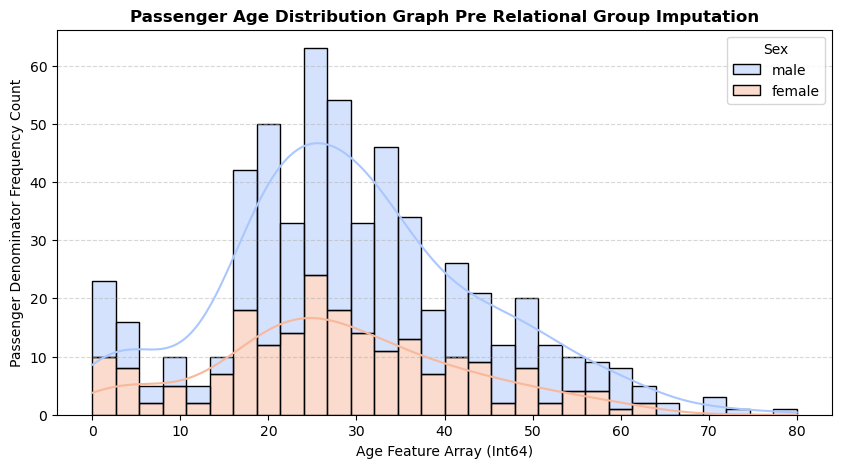

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=X_train, 
    x='Age', 
    hue='Sex', 
    kde=True, 
    multiple='stack', 
    palette='coolwarm', 
    bins=30
)
plt.title('Passenger Age Distribution Graph Pre Relational Group Imputation', fontsize=12, fontweight='bold')
plt.xlabel('Age Feature Array (Int64)')
plt.ylabel('Passenger Denominator Frequency Count')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [22]:
# Filling missing values in Age column
t1_medians=X_train.groupby(['Pclass','Title','SibSp','Parch'])['Age'].median()
t2_medians=X_train.groupby(['Pclass','Title'])['Age'].median()
global_median = X_train['Age'].median()

def simple_imputer(df_split):
    df_split['Age'] = df_split['Age'].astype(float)
    mapped_t1 = pd.Series(df_split.set_index(['Pclass', 'Title', 'SibSp', 'Parch']).index.map(t1_medians), index=df_split.index)
    df_split['Age'] = df_split['Age'].fillna(mapped_t1)
    mapped_t2 = pd.Series(df_split.set_index(['Pclass', 'Title']).index.map(t2_medians), index=df_split.index)
    df_split['Age'] = df_split['Age'].fillna(mapped_t2)
    df_split['Age'] = df_split['Age'].fillna(global_median)
    df_split['Age'] = df_split['Age'].round().astype('Int64')
    return df_split
X_train = simple_imputer(X_train)
X_test = simple_imputer(X_test)

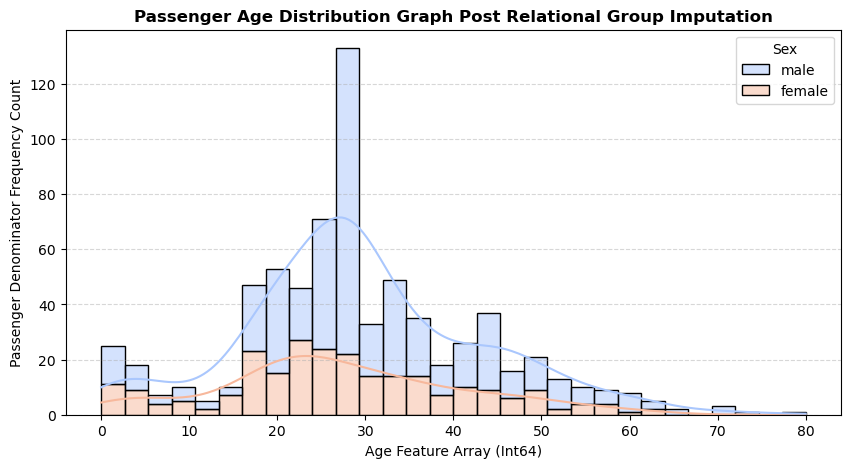

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=X_train, 
    x='Age', 
    hue='Sex', 
    kde=True, 
    multiple='stack', 
    palette='coolwarm', 
    bins=30
)
plt.title('Passenger Age Distribution Graph Post Relational Group Imputation', fontsize=12, fontweight='bold')
plt.xlabel('Age Feature Array (Int64)')
plt.ylabel('Passenger Denominator Frequency Count')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [24]:
# Handling Missing Values in Embarked column
embarked_mode=X_train['Embarked'].mode()[0]
X_train['Embarked']=X_train['Embarked'].fillna(embarked_mode)
X_test['Embarked']=X_test['Embarked'].fillna(embarked_mode)

In [25]:
# 1. Separating numeric and categorical features
numeric_features = ['Age', 'FamilySize', 'Log_Fare', 'SibSp', 'Parch', 'Pclass']
categorical_features = ['Sex', 'Embarked', 'Title', 'Deck', 'Has_Cabin']

# 2. Applying tranformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

X_train_transformed=preprocessor.fit_transform(X_train)
X_test_transformed=preprocessor.transform(X_test)
feature_name=preprocessor.get_feature_names_out()
X_train_transformed=pd.DataFrame(X_train_transformed,columns=feature_name)
X_test_transformed=pd.DataFrame(X_test_transformed,columns=feature_name)

In [26]:
X_train_transformed

,num__Age,num__FamilySize,num__Log_Fare,num__SibSp,num__Parch,num__Pclass,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,...,cat__Title_Royalty,cat__Deck_A,cat__Deck_B,cat__Deck_C,cat__Deck_D,cat__Deck_E,cat__Deck_F,cat__Deck_M,cat__Has_Cabin_Has_Cabin,cat__Has_Cabin_No_Cabin
0,1.223161,-0.554666,0.437404,-0.470722,-0.479342,-1.614136,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.465893,-0.554666,-0.322935,-0.470722,-0.479342,-0.400551,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.195042,-0.554666,-0.782201,-0.470722,-0.479342,0.813034,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,-0.245581,0.040096,-0.790325,0.379923,-0.479342,0.813034,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,-1.714324,3.013909,0.529116,2.931860,2.048742,0.813034,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,-0.612767,-0.554666,-0.814128,-0.470722,-0.479342,0.813034,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
708,1.149724,-0.554666,0.520387,-0.470722,-0.479342,-1.614136,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
709,0.855976,0.634859,-0.245215,1.230569,-0.479342,0.813034,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
710,-1.126827,1.229621,1.877220,0.379923,2.048742,-1.614136,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [27]:
# Check shapes to ensure lengths match
print("Train shape:", X_train_transformed.shape, y_train.shape)
print("Test shape:", X_test_transformed.shape, y_test.shape)

# Quick sanity check for missing values
print("Missing values in Train:", X_train_transformed.isna().sum().sum())


Train shape: (712, 26) (712,)
Test shape: (179, 26) (179,)
Missing values in Train: 0


In [28]:
# Save out the features and targets
X_train_transformed.to_csv('../data/X_train_clean.csv', index=False)
X_test_transformed.to_csv('../data/X_test_clean.csv', index=False)
y_train.to_csv('../data/y_train_clean.csv', index=False)
y_test.to_csv('../data/y_test_clean.csv', index=False)

print(" !! Data exported successfully !!")


 !! Data exported successfully !!
